In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def custom_least_squares(X, Y):

    A = np.vstack([X, np.ones(len(X))]).T
    
    A_T_A = np.dot(A.T, A)
    
    A_T_A_inv = np.linalg.inv(A_T_A)
    
    A_T_Y = np.dot(A.T, Y)
    beta = np.dot(A_T_A_inv, A_T_Y)
    
    return beta[0], beta[1]

In [3]:
X = np.arange(0, 1.01, 0.01)
true_m = 4.5
true_b = 2.0
np.random.seed(42) 
error = np.random.uniform(-1, 1, size=len(X))
Y = true_m * X + true_b + error

In [4]:
custom_m, custom_b = custom_least_squares(X, Y)
A_np = np.vstack([X, np.ones(len(X))]).T
np_m, np_b = np.linalg.lstsq(A_np, Y, rcond=None)[0]
print("--- Model Comparison ---")
print(f"Original Equation: y = {true_m:.4f}x + {true_b:.4f}")
print(f"Custom Method:     y = {custom_m:.4f}x + {custom_b:.4f}")
print(f"Numpy lstsq:       y = {np_m:.4f}x + {np_b:.4f}")
print(f"Difference (m, b): {abs(custom_m - np_m):.4e}, {abs(custom_b - np_b):.4e}\n")

--- Model Comparison ---
Original Equation: y = 4.5000x + 2.0000
Custom Method:     y = 4.4891x + 1.9371
Numpy lstsq:       y = 4.4891x + 1.9371
Difference (m, b): 1.0658e-14, 2.8866e-15



In [5]:
# Residuals = |Actual Y - Predicted Y|
predictions = custom_m * X + custom_b
residuals = np.abs(Y - predictions)

# Identify max and min residuals
max_res_idx = np.argmax(residuals)
min_res_idx = np.argmin(residuals)

print("--- Residual Analysis ---")
print(f"Largest Residual Error:  {residuals[max_res_idx]:.4f} at point X = {X[max_res_idx]:.2f}, Y = {Y[max_res_idx]:.4f}")
print(f"Smallest Residual Error: {residuals[min_res_idx]:.4f} at point X = {X[min_res_idx]:.2f}, Y = {Y[min_res_idx]:.4f}\n")

--- Residual Analysis ---
Largest Residual Error:  1.0442 at point X = 0.69, Y = 6.0788
Smallest Residual Error: 0.0170 at point X = 0.89, Y = 5.9494



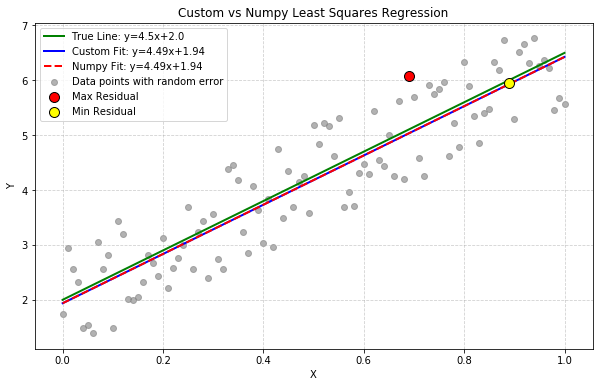

In [6]:
plt.figure(figsize=(10, 6))

# Plot the raw noisy data
plt.scatter(X, Y, color='gray', alpha=0.6, label='Data points with random error')

# Plot the True line
plt.plot(X, true_m * X + true_b, color='green', linewidth=2, label=f'True Line: y={true_m}x+{true_b}')

# Plot Custom Least Squares (Solid Blue)
plt.plot(X, custom_m * X + custom_b, color='blue', linewidth=2, label=f'Custom Fit: y={custom_m:.2f}x+{custom_b:.2f}')

# Plot Numpy Least Squares (Dashed Red to show overlap)
plt.plot(X, np_m * X + np_b, color='red', linestyle='--', linewidth=2, label=f'Numpy Fit: y={np_m:.2f}x+{np_b:.2f}')

# Highlight the max and min residual points
plt.scatter(X[max_res_idx], Y[max_res_idx], color='red', s=100, edgecolor='black', zorder=5, label='Max Residual')
plt.scatter(X[min_res_idx], Y[min_res_idx], color='yellow', s=100, edgecolor='black', zorder=5, label='Min Residual')

plt.title("Custom vs Numpy Least Squares Regression")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()